# ASSIGNMENT 07

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 1. Create a NumPy array of 50 random numbers and find the 2nd largest and 3rd smallest element.
# OUTPUT :

arr = np.random.randint(1, 100, 50)

print("Array:")
print(arr)

sorted_arr = np.sort(arr)

third_smallest = sorted_arr[2]

second_largest = sorted_arr[-2]

print("\n3rd Smallest Element:", third_smallest)
print("2nd Largest Element:", second_largest)

Array:
[16 95 39 25 70 25 53 43  8 60 38 93 79 34 82 82 93 64 27 37 87 39 98 87
 99 36 93 33 58 39 74 34 16 17 62 38 44 17 33 46 87 56 53  1  3 32 65 84
  3 62]

3rd Smallest Element: 3
2nd Largest Element: 98


In [3]:
# 2. Given a DataFrame, identify all columns having more than 20% missing values and remove them.
# OUTPUT :

df = pd.DataFrame({
    'A': [1, 2, np.nan, 4, 5],
    'B': [np.nan, np.nan, np.nan, 4, 5], 
    'C': [1, 2, 3, 4, 5]
})


threshold = len(df) * 0.8 
df_cleaned = df.dropna(axis=1, thresh=threshold)

print(df_cleaned)

     A  C
0  1.0  1
1  2.0  2
2  NaN  3
3  4.0  4
4  5.0  5


In [4]:
# 3. Create a NumPy matrix and find its transpose, determinant, rank, and inverse.
# OUTPUT :

matrix = np.array([[2, 4, 1],
                    [6, 7, 3],
                    [4, 5, 9]])

print("Original Matrix:")
print(matrix)

transpose = matrix.T
print("\nTranspose:")
print(transpose)

det = np.linalg.det(matrix)
print("\nDeterminant:")
print(det)

rank = np.linalg.matrix_rank(matrix)
print("\nRank:")
print(rank)

if det != 0:
    inverse = np.linalg.inv(matrix)
    print("\nInverse:")
    print(inverse)
else:
    print("\nInverse not possible (determinant is 0)")

Original Matrix:
[[2 4 1]
 [6 7 3]
 [4 5 9]]

Transpose:
[[2 6 4]
 [4 7 5]
 [1 3 9]]

Determinant:
-70.00000000000003

Rank:
3

Inverse:
[[-0.68571429  0.44285714 -0.07142857]
 [ 0.6        -0.2         0.        ]
 [-0.02857143 -0.08571429  0.14285714]]


In [5]:
# 4. Using Pandas, find the top 5 categories with the highest average value of a numerical column.
# OUTPUT :

df = pd.DataFrame({
    'Category': ['A', 'A', 'B', 'B', 'C', 'C', 'D', 'E', 'F', 'G'],
    'Value': [10, 20, 50, 60, 10, 15, 80, 90, 100, 5]
})


top_5_categories = df.groupby('Category')['Value'].mean().nlargest(5)
print(top_5_categories)

Category
F    100.0
E     90.0
D     80.0
B     55.0
A     15.0
Name: Value, dtype: float64


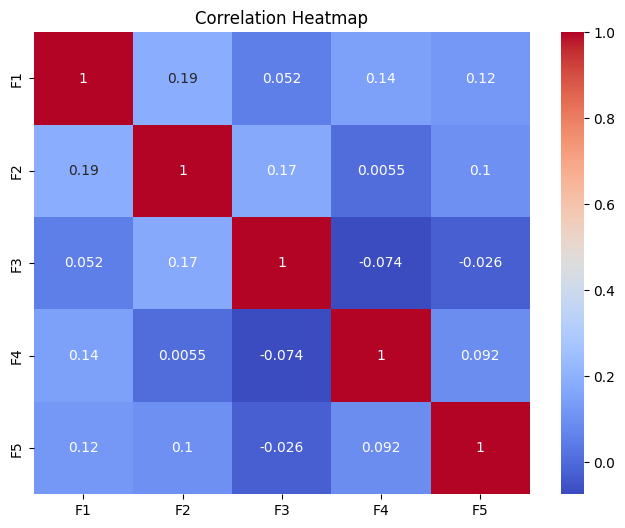

Top 3 Correlated Pairs:
F1  F2    0.188067
F2  F3    0.174505
F4  F1    0.144673
dtype: float64


In [6]:
# 5. Create a Seaborn heatmap and identify the three most highly correlated feature pairs.
# OUTPUT :

df = pd.DataFrame(np.random.rand(100, 5), columns=['F1', 'F2', 'F3', 'F4', 'F5'])
corr_matrix = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

c = corr_matrix.abs().unstack()
c = c[c < 1.0].sort_values(ascending=False).drop_duplicates()
print("Top 3 Correlated Pairs:")
print(c.head(3))

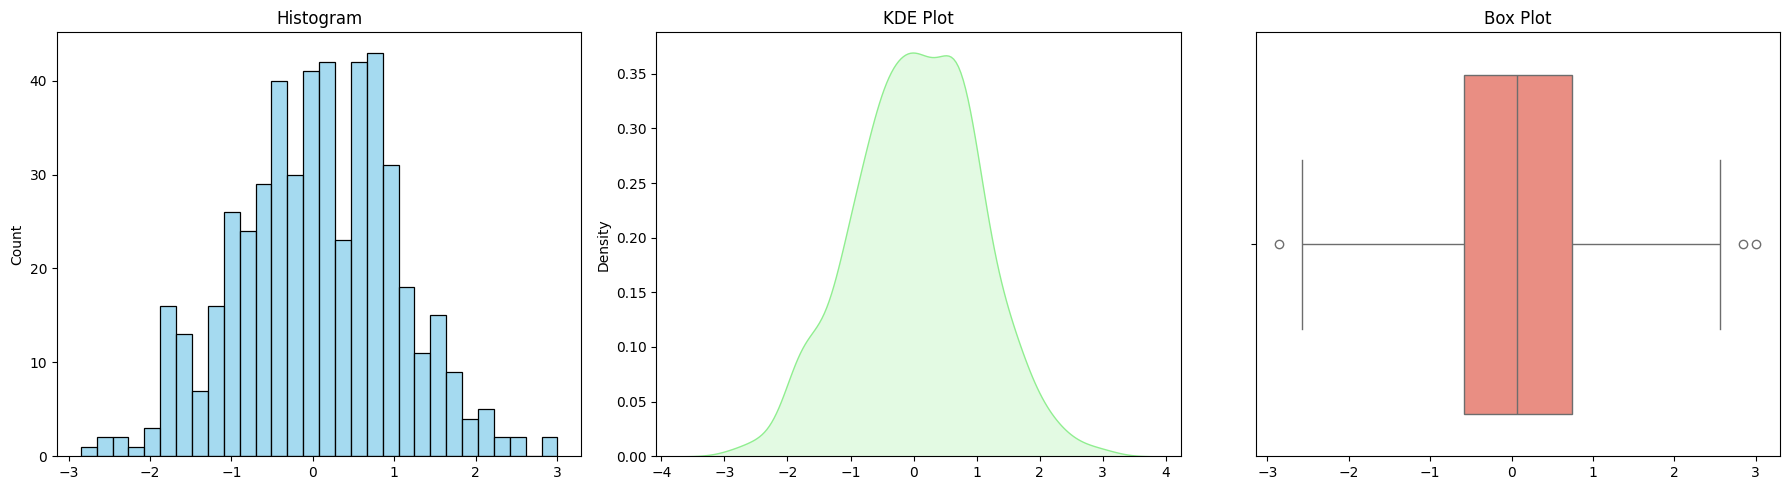

In [7]:
# 6. Generate a dataset with NumPy and visualize its distribution using Histogram, KDE Plot, and Box Plot.
# OUTPUT :

data = np.random.randn(500) 


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram')

sns.kdeplot(data, ax=axes[1], fill=True, color='lightgreen')
axes[1].set_title('KDE Plot')

sns.boxplot(x=data, ax=axes[2], color='salmon')
axes[2].set_title('Box Plot')

plt.tight_layout()
plt.show()

In [8]:
# 7. Using Pandas GroupBy, find the highest, lowest, and average sales for each category.
# OUTPUT :

df = pd.DataFrame({
    'Category': ['Electronics', 'Clothing', 'Electronics', 'Clothing', 'Home', 'Home'],
    'Sales': [200, 50, 300, 80, 150, 100]
})

sales_summary = df.groupby('Category')['Sales'].agg(['max', 'min', 'mean'])
print(sales_summary)

             max  min   mean
Category                    
Clothing      80   50   65.0
Electronics  300  200  250.0
Home         150  100  125.0


Outliers detected:
   Values
6     100
9     -50


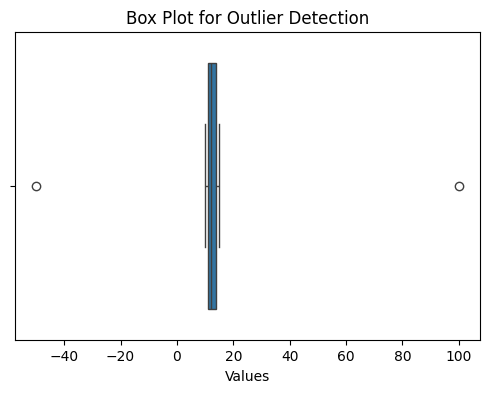

In [9]:
# 8. Detect outliers in a numerical column using the IQR method and visualize them using a Box Plot.
# OUTPUT :

df = pd.DataFrame({'Values': [10, 12, 11, 14, 15, 13, 100, 12, 11, -50]})


Q1 = df['Values'].quantile(0.25)
Q3 = df['Values'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Values'] < lower_bound) | (df['Values'] > upper_bound)]
print(f"Outliers detected:\n{outliers}")


plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Values'])
plt.title("Box Plot for Outlier Detection")
plt.show()

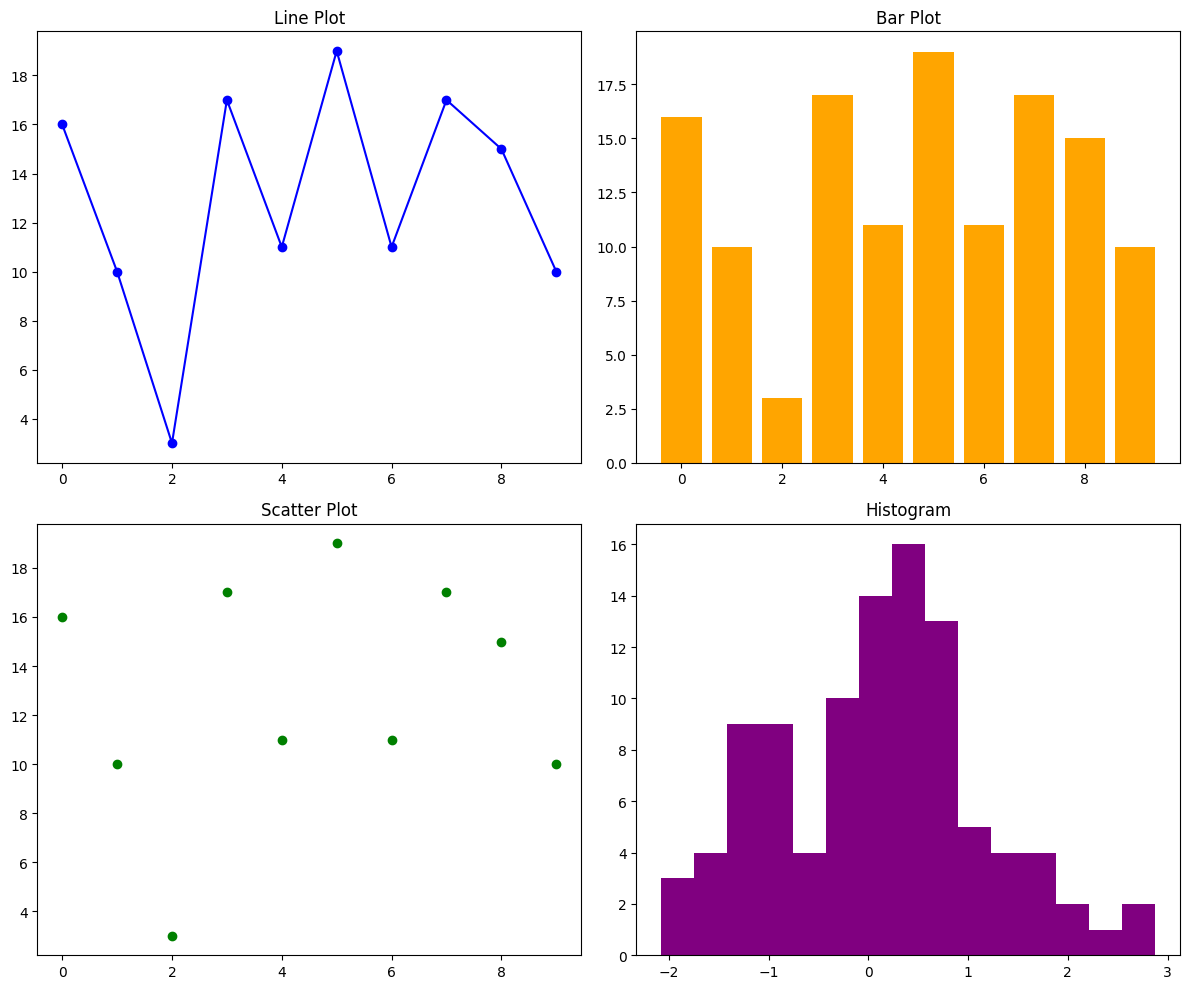

In [10]:
# 9. Create a Matplotlib figure containing 4 subplots:
# o Line Plot
# o Bar Plot
# o Scatter Plot
# o Histogram

# OUTPUT : 

x = np.arange(10)
y = np.random.randint(1, 20, 10)
data = np.random.randn(100)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))


axs[0, 0].plot(x, y, color='blue', marker='o')
axs[0, 0].set_title('Line Plot')


axs[0, 1].bar(x, y, color='orange')
axs[0, 1].set_title('Bar Plot')


axs[1, 0].scatter(x, y, color='green')
axs[1, 0].set_title('Scatter Plot')


axs[1, 1].hist(data, bins=15, color='purple')
axs[1, 1].set_title('Histogram')

plt.tight_layout()
plt.show()

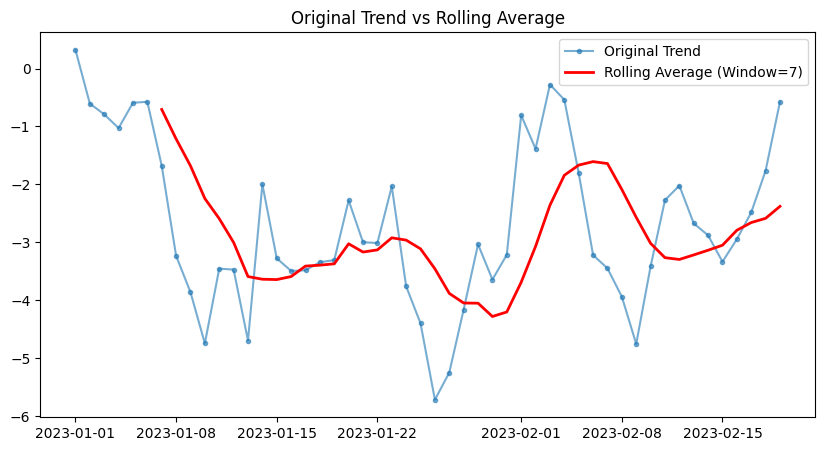

In [11]:
# 10. Create a rolling average of window size 7 on a dataset and compare it with the original trend using Matplotlib
# output :


time_index = pd.date_range('2023-01-01', periods=50)
data_values = np.random.randn(50).cumsum()
df = pd.DataFrame({'Value': data_values}, index=time_index)


df['Rolling_Avg'] = df['Value'].rolling(window=7).mean()


plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Value'], label='Original Trend', alpha=0.6, marker='.')
plt.plot(df.index, df['Rolling_Avg'], label='Rolling Average (Window=7)', color='red', linewidth=2)
plt.title("Original Trend vs Rolling Average")
plt.legend()
plt.show()

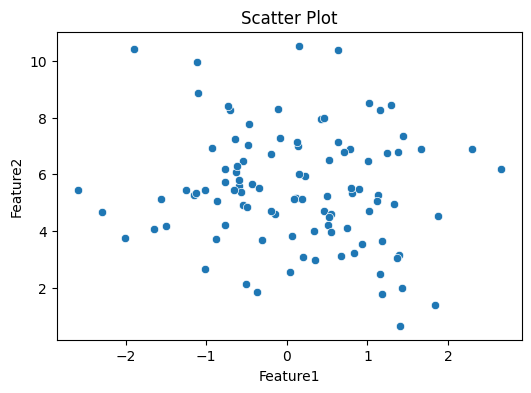

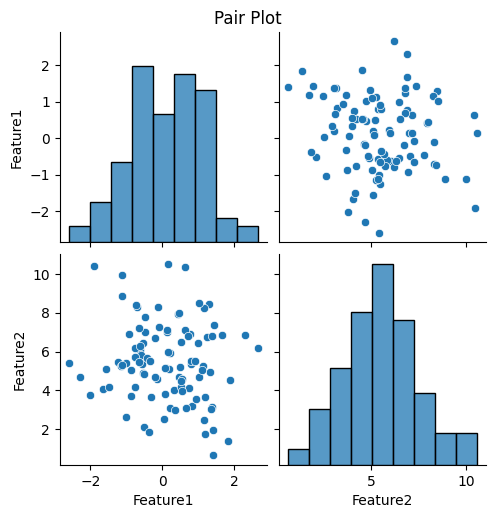

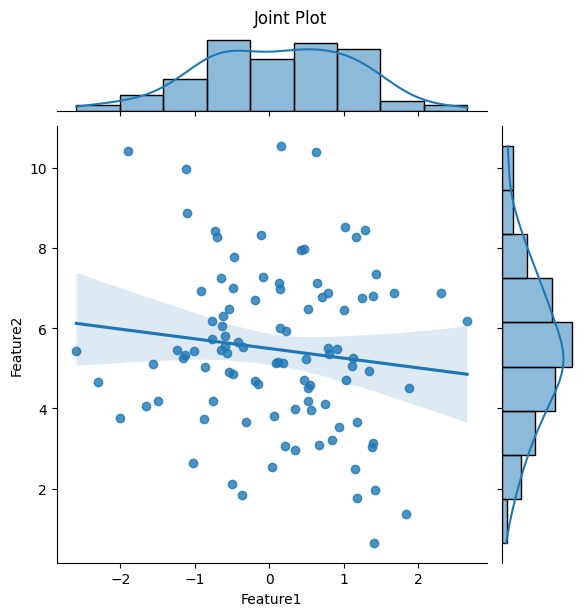

In [12]:
# 11. Using Seaborn, compare two numerical features using:
# ● Scatter Plot
# ● Pair Plot
# ● Joint Plot

# output :

df = pd.DataFrame({
    'Feature1': np.random.randn(100),
    'Feature2': np.random.randn(100) * 2 + 5
})


plt.figure(figsize=(6, 4))
sns.scatterplot(x='Feature1', y='Feature2', data=df)
plt.title("Scatter Plot")
plt.show()


sns.pairplot(df[['Feature1', 'Feature2']])
plt.suptitle("Pair Plot", y=1.02)
plt.show()


sns.jointplot(x='Feature1', y='Feature2', data=df, kind='reg')
plt.suptitle("Joint Plot", y=1.02)
plt.show()

--- MINI EDA REPORT ---

1. Missing Values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

2. Correlation Analysis:


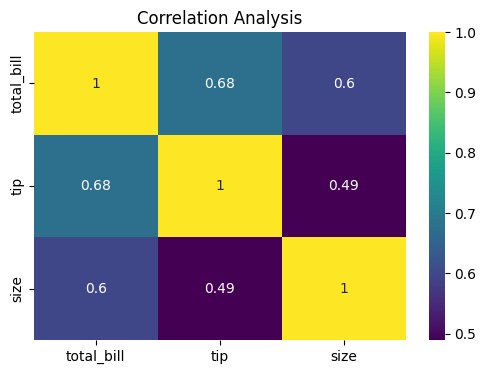


3. Outlier Detection (Box Plot for Total Bill):


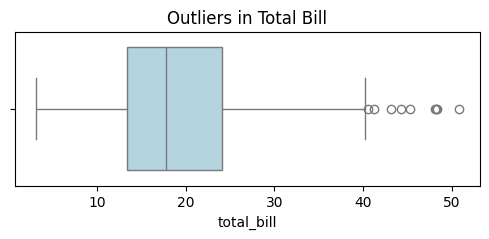


4. Feature Distribution Visualization:


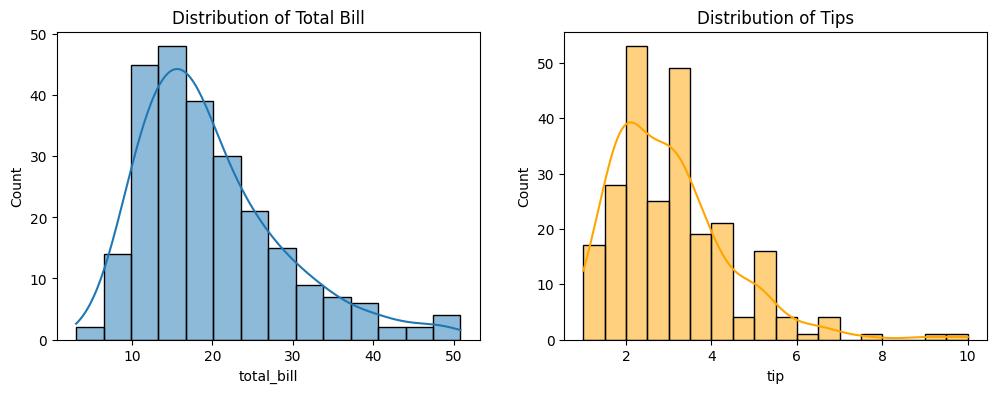

In [13]:
# 12. Build a mini EDA report that includes:
# ● Missing Values Analysis
# ● Correlation Analysis
# ● Outlier Detection
# ● Feature Distribution Visualization

# output :


df = sns.load_dataset('tips')

print("--- MINI EDA REPORT ---")


print("\n1. Missing Values:")
print(df.isnull().sum())


print("\n2. Correlation Analysis:")
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(6, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='viridis')
plt.title('Correlation Analysis')
plt.show()


print("\n3. Outlier Detection (Box Plot for Total Bill):")
plt.figure(figsize=(6, 2))
sns.boxplot(x=df['total_bill'], color='lightblue')
plt.title('Outliers in Total Bill')
plt.show()


print("\n4. Feature Distribution Visualization:")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['total_bill'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Total Bill')
sns.histplot(df['tip'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Tips')
plt.show()


# ASSIGNMENT 09
